In [12]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [13]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_200101_001_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()

#df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_200101_001_0201_SEB.lv0
astri_002_43_009_00002_R_200101_001_0201_SEB.lv0
astri_003_43_009_00002_R_200101_001_0201_SEB.lv0
astri_004_43_009_00002_R_200101_001_0201_SEB.lv0
astri_005_43_009_00002_R_200101_001_0201_SEB.lv0
astri_006_43_009_00002_R_200101_001_0201_SEB.lv0
astri_007_43_009_00002_R_200101_001_0201_SEB.lv0
astri_008_43_009_00002_R_200101_001_0201_SEB.lv0
astri_009_43_009_00002_R_200101_001_0201_SEB.lv0


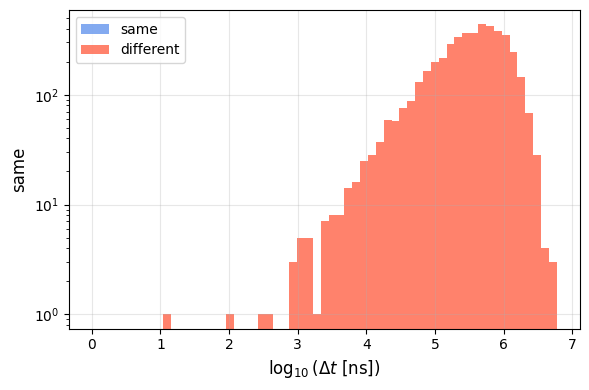

In [14]:
delta_t=np.diff(df_all_sorted["TIME_ABS"])
delta_ts = delta_t[delta_t > 0] #uso maschere e cambio
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.12e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]==1]
#ordino eventi con il for e suddivisione same e different
df_all_sorted=df_all_sorted.sort_values(["MCRUN","EVENT","TIME_ABS"]).reset_index(drop=True)
delta_t_same = []
delta_t_diff = []

for i in range(1, len(df_all_sorted)):
    if ((df_all_sorted.loc[i, "MCRUN"]==df_all_sorted.loc[i-1, "MCRUN"])&
        (df_all_sorted.loc[i, "EVENT"] ==df_all_sorted.loc[i-1, "EVENT"])):
        delta_t_same.append(df_all_sorted.loc[i, "TIME_ABS"]-
                            df_all_sorted.loc[i-1, "TIME_ABS"])
    else:
        delta_t_diff.append(df_all_sorted.loc[i, "TIME_ABS"]-
                            df_all_sorted.loc[i-1, "TIME_ABS"])
delta_t_same = np.array(delta_t_same)
delta_t_diff = np.array(delta_t_diff)
delta_t_same_safe = np.where(delta_t_same > 0, delta_t_same, 1)
delta_t_diff_safe = np.where(delta_t_diff > 0, delta_t_diff, 1)
#suddivido tra stesso evento e evento separato sostituendo i deltat con 1
plt.figure(figsize=(6, 4))
plt.hist(np.log10(delta_t_same[delta_t_same > 0]), bins=50, color='cornflowerblue',
         alpha=0.8,label='same')
plt.hist(np.log10(delta_t_diff[delta_t_diff > 0]),bins=50, color='tomato',
         alpha=0.8,label='different')
plt.yscale('log')
plt.xlabel(r'$\log_{10}(\Delta t\ \mathrm{[ns]})$', fontsize=12)
plt.ylabel('same', fontsize=12)
#plt.xlim(left=0)
plt.tight_layout()
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [15]:

threshold_ns = 1000  # equivalente a log10(delta_t) < 3

#delta_t entro la soglia
delta_t_same_window = delta_t_same[(delta_t_same > 0) & (delta_t_same < threshold_ns)]
delta_t_diff_window = delta_t_diff[(delta_t_diff > 0) & (delta_t_diff < threshold_ns)]

n_same_in_window = len(delta_t_same_window)
n_diff_in_window = len(delta_t_diff_window)
total_in_window = n_same_in_window + n_diff_in_window

print(f"Eventi nella finestra temporale (Δt < {threshold_ns} ns):")
print(f"  - Stesso evento (same): {n_same_in_window} ({n_same_in_window/total_in_window*100:.1f}%)")
print(f"  - Eventi diversi (different): {n_diff_in_window} ({n_diff_in_window/total_in_window*100:.1f}%)")
print(f"  - Totale: {total_in_window}")

# Se vuoi salvare gli indici degli eventi originali nella finestra temporale
indices_same_window = []
indices_diff_window = []

for i in range(1, len(df_all_sorted)):
    dt = df_all_sorted.loc[i, "TIME_ABS"] - df_all_sorted.loc[i-1, "TIME_ABS"]
    
    if 0 < dt < threshold_ns:
        if ((df_all_sorted.loc[i, "MCRUN"] == df_all_sorted.loc[i-1, "MCRUN"]) &
            (df_all_sorted.loc[i, "EVENT"] == df_all_sorted.loc[i-1, "EVENT"])):
            indices_same_window.append(i)
        else:
            indices_diff_window.append(i)

# Crea dataframe con solo gli eventi nella finestra
df_same_window = df_all_sorted.loc[indices_same_window].copy()
df_diff_window = df_all_sorted.loc[indices_diff_window].copy()

print(f"\nRighe del dataframe nella finestra:")
print(f"  - Same events: {len(df_same_window)}")
print(f"  - Different events: {len(df_diff_window)}")


Eventi nella finestra temporale (Δt < 1000 ns):
  - Stesso evento (same): 0 (0.0%)
  - Eventi diversi (different): 7 (100.0%)
  - Totale: 7

Righe del dataframe nella finestra:
  - Same events: 0
  - Different events: 7


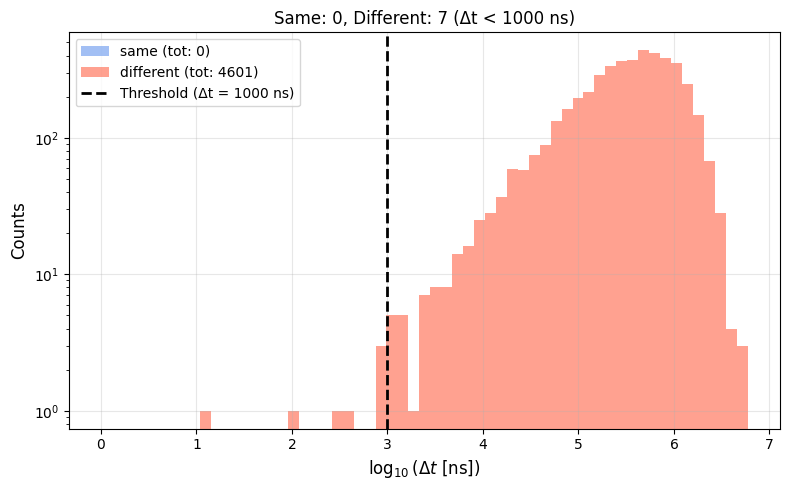

In [16]:

plt.figure(figsize=(8, 5))
plt.hist(np.log10(delta_t_same[delta_t_same > 0]), bins=50, color='cornflowerblue',
         alpha=0.6, label=f'same (tot: {len(delta_t_same[delta_t_same > 0])})')
plt.hist(np.log10(delta_t_diff[delta_t_diff > 0]), bins=50, color='tomato',
         alpha=0.6, label=f'different (tot: {len(delta_t_diff[delta_t_diff > 0])})')

# Linea verticale alla soglia
plt.axvline(x=3, color='black', linestyle='--', linewidth=2, 
            label=f'Threshold (Δt = {threshold_ns} ns)')

plt.yscale('log')
plt.xlabel(r'$\log_{10}(\Delta t\ \mathrm{[ns]})$', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.title(f'Same: {n_same_in_window}, Different: {n_diff_in_window} (Δt < {threshold_ns} ns)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# 1. Assicurarsi che il DataFrame sia ordinato per TIME_ABS
df_all_sorted = df_all_sorted.sort_values('TIME_ABS').reset_index(drop=True)

# 2. Calcolare le differenze temporali tra eventi consecutivi
df_all_sorted['dt'] = df_all_sorted['TIME_ABS'].diff()

# 3. Creare gruppi temporali basati sulla soglia
# Quando dt > threshold_ns, inizia un nuovo gruppo
df_all_sorted['new_group'] = (df_all_sorted['dt'] > threshold_ns) | (df_all_sorted['dt'].isna())
df_all_sorted['time_group'] = df_all_sorted['new_group'].cumsum()

# 4. Identificare se eventi consecutivi hanno stesso EVENT e MCRUN
df_all_sorted['same_event'] = (df_all_sorted['EVENT'] == df_all_sorted['EVENT'].shift(1))
df_all_sorted['same_mcrun'] = (df_all_sorted['MCRUN'] == df_all_sorted['MCRUN'].shift(1))
df_all_sorted['same_event_mcrun'] = df_all_sorted['same_event'] & df_all_sorted['same_mcrun']

# 5. Classificare gli eventi
# same_window: stessa finestra temporale E stesso EVENT/MCRUN
# diff_window: stessa finestra temporale MA EVENT o MCRUN diverso
df_all_sorted['window_type'] = None

# Eventi consecutivi nella stessa finestra temporale (dt <= threshold_ns)
same_time_window = ~df_all_sorted['new_group']

df_all_sorted.loc[same_time_window & df_all_sorted['same_event_mcrun'], 'window_type'] = 'same_window'
df_all_sorted.loc[same_time_window & ~df_all_sorted['same_event_mcrun'], 'window_type'] = 'diff_window'

# 6. Estrarre gli eventi di tipo diff_window
diff_window_events = df_all_sorted[df_all_sorted['window_type'] == 'diff_window']

# 7. Identificare tutti i time_group che contengono eventi diff_window
affected_time_groups = diff_window_events['time_group'].unique()

# 8. Estrarre tutti gli eventi appartenenti a questi gruppi temporali
df_linked_events = df_all_sorted[df_all_sorted['time_group'].isin(affected_time_groups)].copy()

# 9. Pulizia: rimuovere colonne temporanee se necessario
df_all_sorted = df_all_sorted.drop(columns=['new_group', 'same_event', 'same_mcrun', 'same_event_mcrun'])

# Risultati
print(f"Numero totale di rette: {len(df_all_sorted)}")
print(f"Numero totale di eventi (event, mcrun): {df_all_sorted.groupby(['EVENT', 'MCRUN']).ngroups}")
print(f"Numero totale di eventi SEB : {df_all_sorted.groupby(['time_group']).ngroups}")
#print(df_linked_events['dt'].max())
#print(df_all_sorted['dt'].max())

#print(df_linked_events.columns)
print(f"Numero di finestre temporali: {df_all_sorted['time_group'].nunique()}")
print(f"rette in same_window: {(df_all_sorted['window_type'] == 'same_window').sum()}")
print(f"rette in diff_window: {(df_all_sorted['window_type'] == 'diff_window').sum()}")
print(f"Numero di finestre temporali con eventi misti: {len(affected_time_groups)}")
print(f"Numero totale di eventi SEB (in cui si può distinguere): {df_linked_events.groupby(['time_group']).ngroups}")

Numero totale di rette: 4608
Numero totale di eventi (event, mcrun): 4608
Numero totale di eventi SEB : 4595
Numero di finestre temporali: 4595
rette in same_window: 0
rette in diff_window: 13
Numero di finestre temporali con eventi misti: 13
Numero totale di eventi SEB (in cui si può distinguere): 13



TIME GROUP 1
Telescopi: 1 | Eventi: [1806] | MCRUN: [220000]


/tmp/ipykernel_608726/241945760.py:69: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_hg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()],
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/tmp/ipykernel_608726/241945760.py:71: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_lg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()],


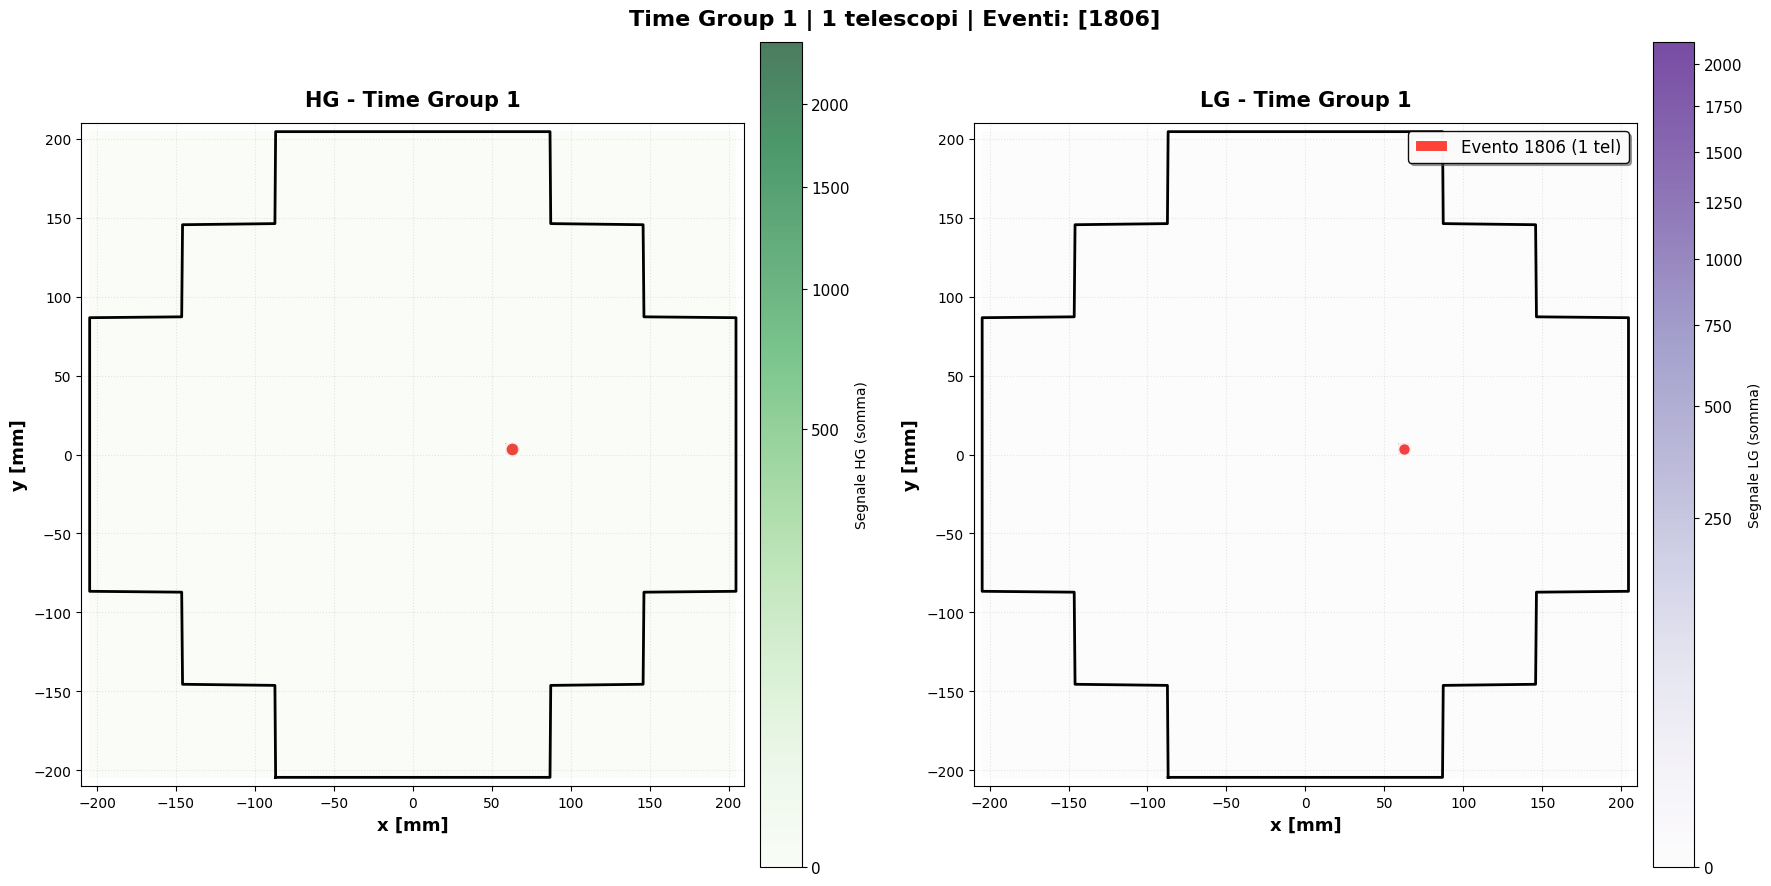

✓ Completato time_group 1
  Rette per evento: {1806: 1}


TIME GROUP 2
Telescopi: 1 | Eventi: [1816] | MCRUN: [220000]


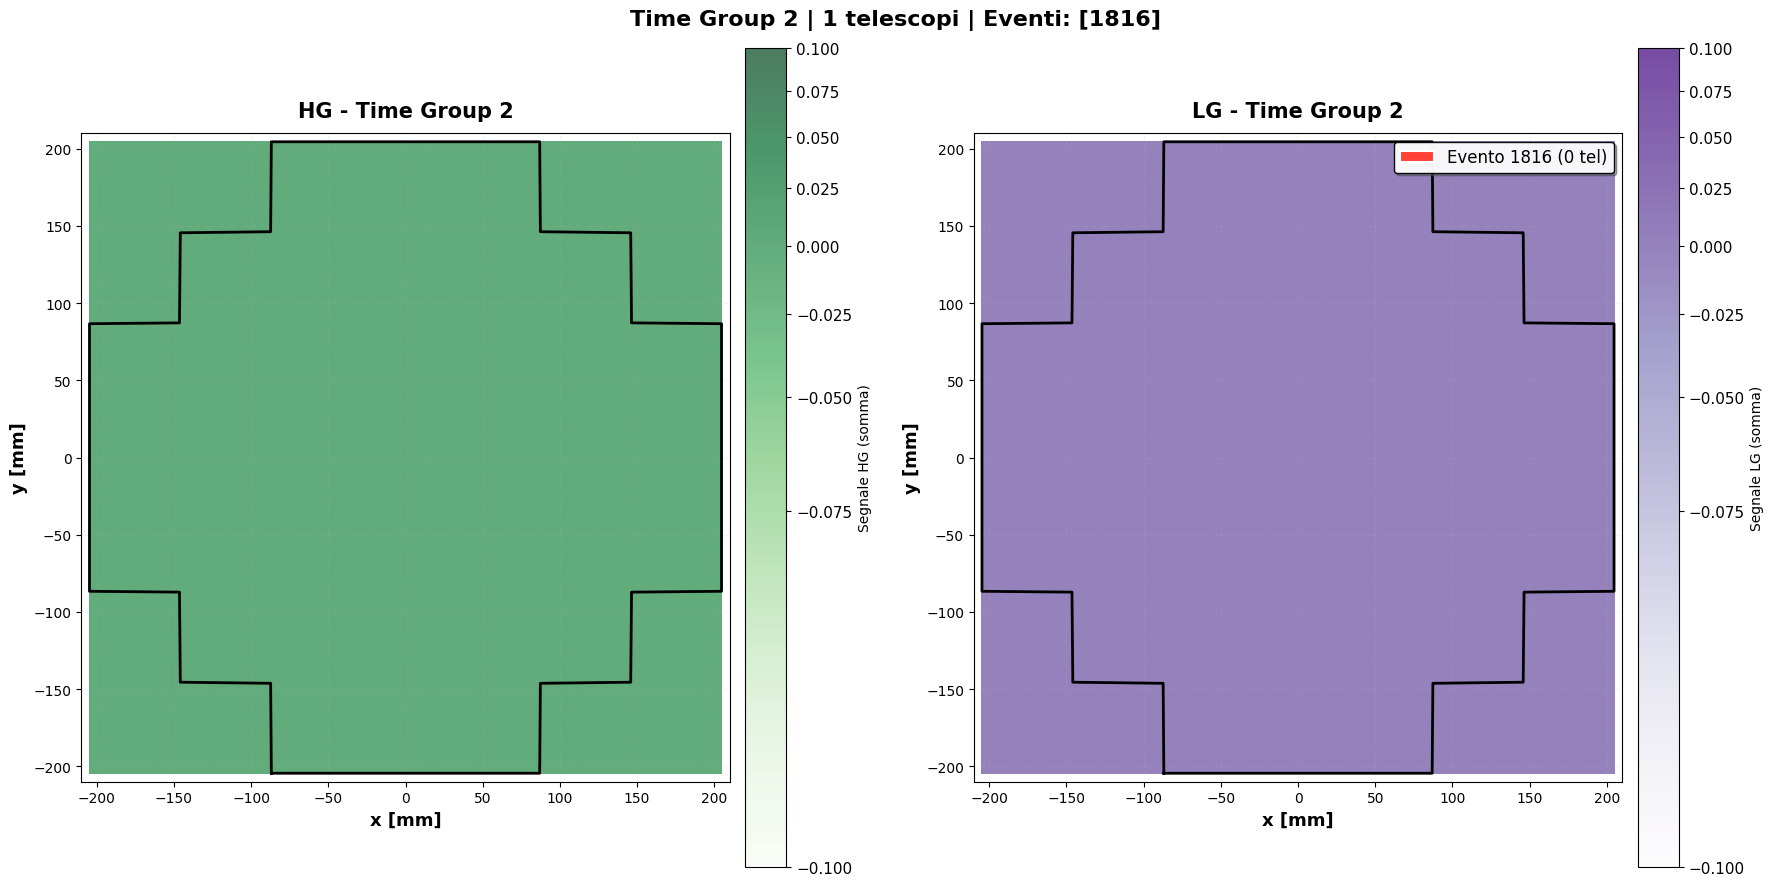

✓ Completato time_group 2
  Rette per evento: {1816: 0}


TIME GROUP 3
Telescopi: 1 | Eventi: [2114] | MCRUN: [220000]


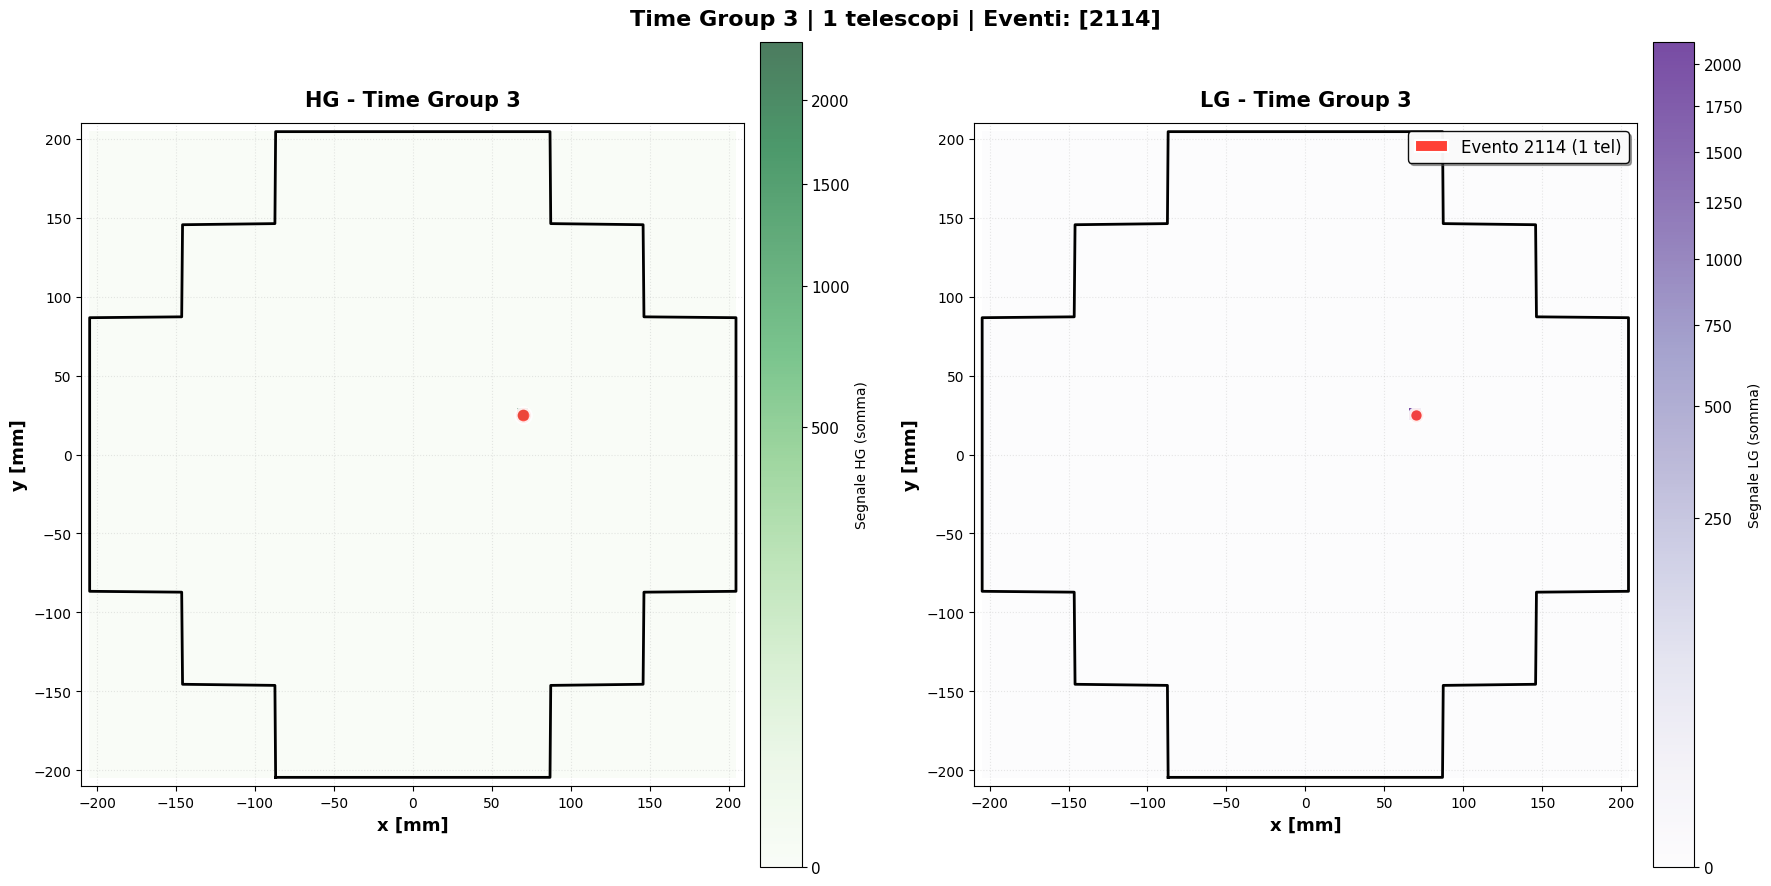

✓ Completato time_group 3
  Rette per evento: {2114: 1}



In [18]:

from matplotlib.colors import PowerNorm
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)
for time_group in df_all_sorted['time_group'].drop_duplicates().values[:3]:
    
    # Estrai tutti gli eventi di questo gruppo temporale
    df_window = df_all_sorted[df_all_sorted['time_group'] == time_group].copy()
    
    # Informazioni sul gruppo
    unique_events = df_window['EVENT'].unique()
    unique_mcruns = df_window['MCRUN'].unique()
    
    print(f"\n{'='*70}")
    print(f"TIME GROUP {time_group}")
    print(f"Telescopi: {len(df_window)} | Eventi: {unique_events} | MCRUN: {unique_mcruns}")
    print(f"{'='*70}")
    
    # Ordina per shape
    df_window = df_window.sort_values(by='shape', ascending=False).reset_index(drop=True)
    
    # Inizializza array per sommare le immagini
    weights_hg = np.zeros_like(np.array(df_window['HG'].iloc[0]))
    weights_lg = np.zeros_like(np.array(df_window['LG'].iloc[0]))
    mask_tot = np.zeros((37, 64), dtype=bool)
    
    # Crea figura side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(18, 9))
    
    # Lunghezza rette
    xmin, xmax = np.min(xfp), np.max(xfp)
    ymin, ymax = np.min(yfp), np.max(yfp)
    diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
    L = 0.45 * diag
    
    # Colori per eventi (più vivaci)
    colors = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B']  # rosso, blu, verde, arancione
    event_color_map = {unique_events[i]: colors[i % len(colors)] for i in range(len(unique_events))}
    
    # Liste per contare rette per evento
    rette_per_evento = {ev: 0 for ev in unique_events}
    
    # Itera su tutti i telescopi del gruppo
    for idx, row in df_window.iterrows():
        
        hgev = np.array(row['HG'])
        lgev = np.array(row['LG'])
        ttpev = np.array(row['TTP'])
        
        # mask di pixel buoni
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # Somma le immagini
        weights_hg[pxmask] += hgev[pxmask]
        weights_lg[pxmask] += lgev[pxmask]
        mask_tot |= pxmask
        
        # Centroidi
        meanx_hg = np.average(x_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meany_hg = np.average(y_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meanx_lg = np.average(x_pix[pxmask].flatten(), weights=lgev[pxmask].flatten())
        meany_lg = np.average(y_pix[pxmask].flatten(), weights=lgev[pxmask].flatten())
        
        # Covarianze
        cov_hg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=hgev[pxmask].flatten())
        cov_lg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=lgev[pxmask].flatten())
        
        # Parametri ellisse
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0] - cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])
        
        # Colore basato sull'evento
        color_ev = event_color_map[row['EVENT']]
        rette_per_evento[row['EVENT']] += 1
        
        # ===== HG (sinistra) =====
        ax[0].scatter(meanx_hg, meany_hg, s=120, color=color_ev, 
                      edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_hg - L * np.cos(theta_hg)
        y1 = meany_hg - L * np.sin(theta_hg)
        x2 = meanx_hg + L * np.cos(theta_hg)
        y2 = meany_hg + L * np.sin(theta_hg)
        ax[0].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
        
        # ===== LG (destra) =====
        ax[1].scatter(meanx_lg, meany_lg, s=100, color=color_ev, 
                      edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_lg - L * np.cos(theta_lg)
        y1 = meany_lg - L * np.sin(theta_lg)
        x2 = meanx_lg + L * np.cos(theta_lg)
        y2 = meany_lg + L * np.sin(theta_lg)
        ax[1].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
    
    # Heatmap somma
    weights_hg = np.array(weights_hg)
    weights_lg = np.array(weights_lg)
    
    h1 = ax[0].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                      weights=weights_hg[mask_tot].flatten(), 
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Greens', alpha=0.7, norm=PowerNorm(0.4))
    
    h2 = ax[1].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                      weights=weights_lg[mask_tot].flatten(), 
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Purples', alpha=0.7, norm=PowerNorm(0.4))
    
    # Footprint camera
    for a in ax:
        a.plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
        a.set_xlim(-210, 210)
        a.set_ylim(-210, 210)
        a.set_aspect('equal')
        a.set_xlabel('x [mm]', fontsize=13, fontweight='bold')
        a.set_ylabel('y [mm]', fontsize=13, fontweight='bold')
        a.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    
    ax[0].set_title(f'HG - Time Group {time_group}', fontweight='bold', fontsize=15, pad=12)
    ax[1].set_title(f'LG - Time Group {time_group}', fontweight='bold', fontsize=15, pad=12)
    
    # Colorbar
    cbar1 = fig.colorbar(h1[3], ax=ax[0], label='Segnale HG (somma)', pad=0.02)
    cbar2 = fig.colorbar(h2[3], ax=ax[1], label='Segnale LG (somma)', pad=0.02)
    cbar1.ax.tick_params(labelsize=11)
    cbar2.ax.tick_params(labelsize=11)
    
    # Legenda eventi
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=event_color_map[ev], edgecolor='white', linewidth=1.5,
              label=f'Evento {ev} ({rette_per_evento[ev]} tel)')
        for ev in unique_events
    ]
    ax[1].legend(handles=legend_elements, loc='upper right', fontsize=12, 
                 framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    plt.suptitle(f'Time Group {time_group} | {len(df_window)} telescopi | Eventi: {list(unique_events)}',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Completato time_group {time_group}")
    print(f"  Rette per evento: {rette_per_evento}\n")

In [19]:
#inizio l'analisi con il mio metodo
# ======================= FUNZIONI GEOMETRICHE =======================

def intersection(p1, d1, p2, d2, eps_ang=1e-1, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])
def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])


In [20]:



def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
#df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
#df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]



xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

results = []

for time_group, df_evt in df_all_sorted.groupby('time_group'):
    
    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        event = row["EVENT"]      # ← PRESO DALLA RIGA, non .unique()
        mcrun = row["MCRUN"]      # ← PRESO DALLA RIGA, non .unique()
        
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if np.sum(pxmask) < 2:
            continue
        
        # SIGMA-CLIPPING
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "time_group": int(time_group),
            "event": int(event),       # ← Converti a int
            "mcrun": int(mcrun),       # ← Converti a int
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": int(itel)       # ← Converti anche questo
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": int(itel)       # ← Converti anche questo
            }
        })

print(f"Creati {len(results)} risultati")
dfR = pd.DataFrame(results)


Creati 1849 risultati


In [21]:
# ======================= CALCOLO INTERSEZIONI =======================
inters_hg = []
inters_lg = []
dfR = pd.DataFrame(results)
print(dfR.head(10))

for time_group, df_evt in dfR.groupby('time_group'):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            P = intersection(rette_hg[i]["p0"], d1,rette_hg[j]["p0"], d2)

            if P is None:
                continue

            inters_hg.append({
                "time_group":time_group,
                "event": event,
                "mcrun": mcrun,
                "d1": d1,
                "d2": d2,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue
              
            inters_lg.append({
                "time_group":time_group,
                "event_arr": event,
                "mcrun_arr": mcrun,
                "d1": d1,
                "d2": d2,
                "P": P,
                "pair": (i, j)
            })

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)
#print("NaN values:", np.isnan(P).sum())

   time_group  event   mcrun  \
0           5   3109  220000   
1           6   6217  220000   
2           9  10103  220000   
3          12  13404  220000   
4          16  18310  220000   
5          17  19101  220000   
6          18  21715  220000   
7          19  22914  220000   
8          23  24810  220000   
9          24  27218  220000   

                                                  HG  \
0  {'p0': [-57.29279289787454, 19.82122308968377]...   
1  {'p0': [39.96889574684612, 97.05071207592493],...   
2  {'p0': [44.577187692619624, -92.21799079480941...   
3  {'p0': [-106.06102592592593, 129.0450954732510...   
4  {'p0': [-90.20012205761317, -3.754192235939642...   
5  {'p0': [-79.76614831980582, 110.43682887810058...   
6  {'p0': [-80.3053080845771, -114.21331932006635...   
7  {'p0': [186.4866600331479, -62.54195757862752]...   
8  {'p0': [95.23894736188701, 48.04615139664805],...   
9  {'p0': [41.96801942915393, 46.34557571865443],...   

                              

In [22]:

from sklearn.cluster import DBSCAN
epsilon = 295
min_samples = 1

# ======================= HG =======================
dist_hg= []

for time_group, df_evt in df_int_hg.groupby("time_group"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    # clustering DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # rette dell'evento falso
    dfR_evt = dfR.loc[dfR["time_group"] == time_group, "HG"]   
    p0  = np.vstack([r["p0"] for r in dfR_evt])
    d   = np.vstack([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    events = dfR.loc[dfR["time_group"] == time_group, "event"].values
    mcruns = dfR.loc[dfR["time_group"] == time_group, "mcrun"].values

    # ciclo cluster
    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # ---------- calcolo pesi angolari ----------
        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)   # sin^2(theta)

        w = np.array(w)

        # ---------- media pesata e semplice ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)
        evt_arr = dfR.loc[dfR["time_group"] == time_group, "event"].values
        mc_arr  = dfR.loc[dfR["time_group"] == time_group, "mcrun"].values
        for t, dm_s, dm_w, dmed, evt, mc in zip(
            tel, dist_mean_simple, dist_mean_weighted, dist_median,evt_arr,mc_arr):
            dist_hg.append({
                "time_group": time_group,
                "event" : evt,
                "mcrun": mc,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_weight": dm_w,
                "d_median": dmed
            })

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []

for time_group, df_evt in df_int_lg.groupby("time_group"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[dfR["time_group"] == time_group, "LG"]   
    p0  = np.vstack([r["p0"] for r in dfR_evt])
    d   = np.vstack([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    events = dfR.loc[dfR["time_group"] == time_group, "event"].values
    mcruns = dfR.loc[dfR["time_group"] == time_group, "mcrun"].values

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)

        w = np.array(w)

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)
        evt_arr = dfR.loc[dfR["time_group"] == time_group, "event"].values
        mc_arr  = dfR.loc[dfR["time_group"] == time_group, "mcrun"].values
        for t, dm_s, dm_w, dmed, evt, mc in zip(
            tel, dist_mean_simple, dist_mean_weighted, dist_median,evt_arr,mc_arr):
            dist_lg.append({
                "time_group": time_group,
                "event" : evt,
                "mcrun": mc,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_weight": dm_w,
                "d_median": dmed
            })

df_dist_lg = pd.DataFrame(dist_lg)
#print(df_dist_hg_f)
#df_dist_hg_f[["time_group","event","mcrun","tel","cluster"]].head(20)
df_dist_hg.columns


KeyError: 'time_group'

In [ ]:
from sklearn.cluster import DBSCAN
epsilon = 295
min_samples = 1

# ======================= HG =======================
dist_hg = []

for time_group, df_evt in df_int_hg.groupby("time_group"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    # clustering DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # Rette del time_group
    dfR_evt = dfR[dfR["time_group"] == time_group]
    
    # CREA DIZIONARIO tel -> (event, mcrun)
    tel_to_event = {}
    for _, row in dfR_evt.iterrows():
        tel_id = row["HG"]["tel"]
        tel_to_event[tel_id] = (row["event"], row["mcrun"])
    
    # Estrai parametri rette
    p0 = np.vstack([r["p0"] for r in dfR_evt["HG"]])
    d = np.vstack([r["d"] for r in dfR_evt["HG"]])
    tel = np.array([r["tel"] for r in dfR_evt["HG"]])

    # ciclo cluster
    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # ---------- calcolo pesi angolari ----------
        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)   # sin^2(theta)

        w = np.array(w)

        # ---------- media pesata e semplice ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)
        
        # Per ogni retta, prendi il SUO event e mcrun
        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            
            # Estrai event e mcrun SPECIFICI di questa retta
            evt, mc = tel_to_event[int(t)]
            
            dist_hg.append({
                "time_group": int(time_group),
                "event": int(evt),
                "mcrun": int(mc),
                "cluster": int(lab),
                "tel": int(t),
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": float(dm_s),
                "d_weight": float(dm_w),
                "d_median": float(dmed)
            })

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []

for time_group, df_evt in df_int_lg.groupby("time_group"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # Rette del time_group
    dfR_evt = dfR[dfR["time_group"] == time_group]
    
    # CREA DIZIONARIO tel -> (event, mcrun)
    tel_to_event = {}
    for _, row in dfR_evt.iterrows():
        tel_id = row["LG"]["tel"]
        tel_to_event[tel_id] = (row["event"], row["mcrun"])
    
    # Estrai parametri rette
    p0 = np.vstack([r["p0"] for r in dfR_evt["LG"]])
    d = np.vstack([r["d"] for r in dfR_evt["LG"]])
    tel = np.array([r["tel"] for r in dfR_evt["LG"]])

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)

        w = np.array(w)

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)
        
        # Per ogni retta, prendi il SUO event e mcrun
        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            
            # Estrai event e mcrun SPECIFICI di questa retta
            evt, mc = tel_to_event[int(t)]
            
            dist_lg.append({
                "time_group": int(time_group),
                "event": int(evt),
                "mcrun": int(mc),
                "cluster": int(lab),
                "tel": int(t),
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": float(dm_s),
                "d_weight": float(dm_w),
                "d_median": float(dmed)
            })

df_dist_lg = pd.DataFrame(dist_lg)

KeyError: 'time_group'

In [ ]:
for fevent, df_evt in dfR.groupby("time_group"):
    print(f"time_group{fevent} ha {len(df_evt)} rette, telescopi: {df_evt['HG'].apply(lambda r: r['tel']).tolist()}")
dfR = dfR.groupby("time_group").filter(lambda df_evt: df_evt['HG'].apply(lambda r: r['tel']).nunique() >= 2)
print("filtraggio")
for fevent, df_evt in dfR.groupby("time_group"):
    print(f"time_group{fevent} ha {len(df_evt)} rette, telescopi: {df_evt['HG'].apply(lambda r: r['tel']).tolist()}")

time_group1 ha 9 rette, telescopi: [1, 4, 3, 2, 7, 6, 5, 8, 9]
time_group4 ha 1 rette, telescopi: [9]
time_group7 ha 4 rette, telescopi: [1, 2, 3, 4]
time_group8 ha 1 rette, telescopi: [9]
time_group9 ha 4 rette, telescopi: [5, 6, 8, 9]
time_group10 ha 1 rette, telescopi: [6]
time_group11 ha 4 rette, telescopi: [4, 7, 6, 9]
time_group12 ha 6 rette, telescopi: [1, 4, 2, 3, 6, 5]
time_group13 ha 2 rette, telescopi: [8, 9]
time_group14 ha 3 rette, telescopi: [1, 4, 3]
time_group15 ha 2 rette, telescopi: [2, 6]
time_group16 ha 1 rette, telescopi: [7]
time_group18 ha 1 rette, telescopi: [2]
time_group19 ha 1 rette, telescopi: [4]
time_group21 ha 2 rette, telescopi: [5, 8]
time_group22 ha 1 rette, telescopi: [9]
time_group23 ha 2 rette, telescopi: [2, 3]
time_group28 ha 1 rette, telescopi: [9]
time_group29 ha 1 rette, telescopi: [1]
time_group30 ha 2 rette, telescopi: [1, 2]
time_group31 ha 7 rette, telescopi: [1, 2, 3, 4, 5, 6, 7]
time_group32 ha 2 rette, telescopi: [7, 9]
time_group35 ha 1

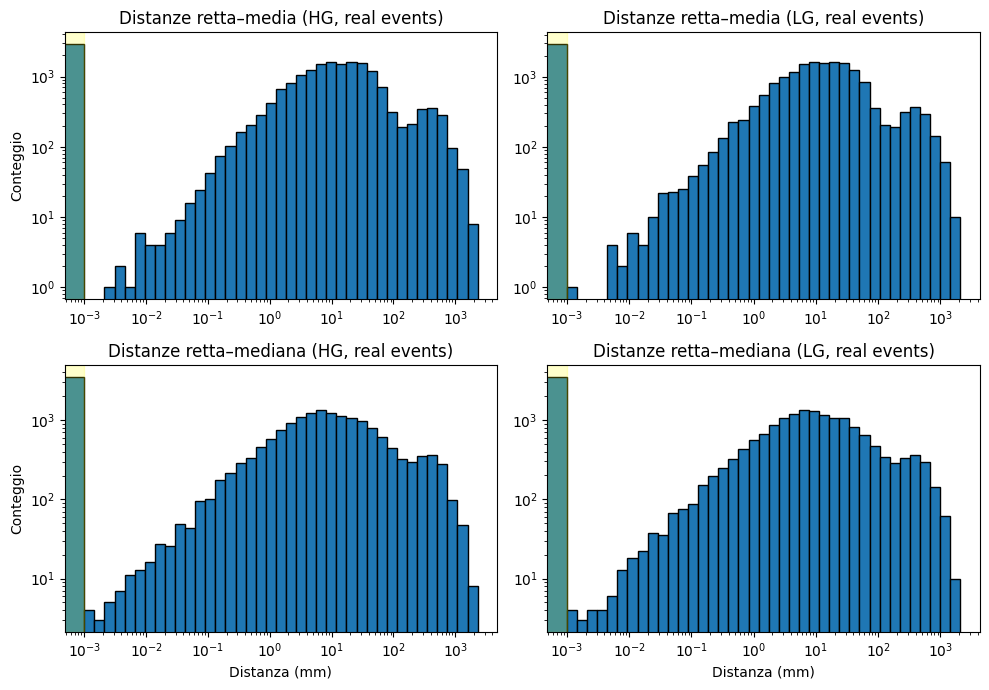

In [ ]:

# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg  = df_dist_lg["d_weight"].values
d_median_lg = df_dist_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=40, zero_threshold=0.001):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg)
bins_median_hg = smart_bins(d_median_hg)
bins_mean_lg   = smart_bins(d_mean_lg)
bins_median_lg = smart_bins(d_median_lg)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, real events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, real events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, real events)")

axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, real events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.axvspan(0, 0.001, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


In [ ]:
# ======================= ASSEGNAZIONE CLUSTER PER HG =======================

def assign_clusters(df_dist, threshold=60):
    """
    Assegna ogni retta al cluster più vicino se distanza <= threshold.
    Altrimenti marca come non assegnata.
    """
    results = []
    
    # Raggruppa per (time_group, ogni combinazione è una retta unica
    for (tg, tel), group in df_dist.groupby(['time_group', 'tel']):
        
        # Trova il cluster con distanza minima
        idx_min = group['d_median'].idxmin()
        min_dist = group.loc[idx_min, 'd_median']
        best_cluster = group.loc[idx_min, 'cluster']
        
        # Prendi le altre info (event, mcrun sono uguali per questa retta)
        event = group.loc[idx_min, 'event']
        mcrun = group.loc[idx_min, 'mcrun']
        P_median = group.loc[idx_min, 'P_median']
        
        # Assegna o marca come non assegnata
        if min_dist <= threshold:
            assigned_cluster = best_cluster
            is_assigned = True
        else:
            assigned_cluster = -1  # -1 indica "non assegnato"
            is_assigned = False
        if isinstance(event, np.ndarray):
            event = int(event[0]) if len(event) > 0 else -1
        else:
            event = int(event)
            
        if isinstance(mcrun, np.ndarray):
            mcrun = int(mcrun[0]) if len(mcrun) > 0 else -1
        else:
            mcrun = int(mcrun)
        results.append({
           
            'time_group': int(tg),
            'tel': int(tel),
            'event': int(event) if event is not None else -1,
            'mcrun': int(mcrun) if mcrun is not None else -1,
            'assigned_cluster': assigned_cluster,
            'is_assigned': is_assigned,
            'min_distance': min_dist,
            'n_clusters_available': len(group)  # quanti cluster erano disponibili
        })
    
    return pd.DataFrame(results)

# Applica l'assegnazione
df_assigned_hg = assign_clusters(df_dist_hg, threshold=60)
df_assigned_lg = assign_clusters(df_dist_lg, threshold=60)

# ======================= STATISTICHE =======================

print("="*70)
print("HG - Statistiche assegnazione")
print("="*70)
print(f"Rette totali: {len(df_assigned_hg)}")
print(f"Rette assegnate: {df_assigned_hg['is_assigned'].sum()}")
print(f"Rette non assegnate: {(~df_assigned_hg['is_assigned']).sum()}")
print(f"Percentuale assegnate: {100*df_assigned_hg['is_assigned'].mean():.1f}%")
print(f"\nDistribuzione cluster assegnati:")
print(df_assigned_hg[df_assigned_hg['is_assigned']]['assigned_cluster'].value_counts().sort_index())

print("\n" + "="*70)
print("LG - Statistiche assegnazione")
print("="*70)
print(f"Rette totali: {len(df_assigned_lg)}")
print(f"Rette assegnate: {df_assigned_lg['is_assigned'].sum()}")
print(f"Rette non assegnate: {(~df_assigned_lg['is_assigned']).sum()}")
print(f"Percentuale assegnate: {100*df_assigned_lg['is_assigned'].mean():.1f}%")
print(f"\nDistribuzione cluster assegnati:")
print(df_assigned_lg[df_assigned_lg['is_assigned']]['assigned_cluster'].value_counts().sort_index())

# ======================= VISUALIZZA ESEMPI =======================

print("\n" + "="*70)
print("Esempi HG:")
print("="*70)
print(df_assigned_hg.head(10))

print("\n" + "="*70)
print("Esempi di rette NON assegnate (HG):")
print("="*70)
print(df_assigned_hg[~df_assigned_hg['is_assigned']].head(5))

HG - Statistiche assegnazione
Rette totali: 17983
Rette assegnate: 17261
Rette non assegnate: 722
Percentuale assegnate: 96.0%

Distribuzione cluster assegnati:
assigned_cluster
0    16366
1      764
2      120
3       10
4        1
Name: count, dtype: int64

LG - Statistiche assegnazione
Rette totali: 17985
Rette assegnate: 17268
Rette non assegnate: 717
Percentuale assegnate: 96.0%

Distribuzione cluster assegnati:
assigned_cluster
0    16372
1      764
2      123
3        9
Name: count, dtype: int64

Esempi HG:
   time_group  tel  event   mcrun  assigned_cluster  is_assigned  \
0           1    1   1007  220000                 0         True   
1           1    2   1007  220000                 0         True   
2           1    3   1007  220000                 0         True   
3           1    4   1007  220000                 0         True   
4           1    5   1007  220000                 0         True   
5           1    6   1007  220000                 0         True   
6   

In [ ]:
print("Tipo di df_assigned_hg:", type(df_assigned_hg))
print("\nColonne:", df_assigned_hg.columns.tolist())
print("\nPrime righe:")
print(df_assigned_hg.head())

print("\nTipo di ogni valore nella prima riga:")
for col in df_assigned_hg.columns:
    val = df_assigned_hg[col].iloc[0]
    print(f"  {col}: {type(val)} = {val}")

# Prova a fare drop_duplicates su colonne singole
print("\nTest drop_duplicates su colonne individuali:")
for col in ['time_group', 'tel', 'event', 'mcrun']:
    try:
        test = df_assigned_hg[[col]].drop_duplicates()
        print(f"  {col}: OK")
    except Exception as e:
        print(f"  {col}: ERRORE - {e}")

# Test su coppie di colonne
print("\nTest su [event, mcrun]:")
try:
    test = df_assigned_hg[['event', 'mcrun']].drop_duplicates()
    print("  OK")
except Exception as e:
    print(f"  ERRORE: {e}")
    print(f"  Tipo event: {type(df_assigned_hg['event'].iloc[0])}")
    print(f"  Tipo mcrun: {type(df_assigned_hg['mcrun'].iloc[0])}")

Tipo di df_assigned_hg: <class 'pandas.core.frame.DataFrame'>

Colonne: ['time_group', 'tel', 'event', 'mcrun', 'assigned_cluster', 'is_assigned', 'min_distance', 'n_clusters_available']

Prime righe:
   time_group  tel  event   mcrun  assigned_cluster  is_assigned  \
0           1    1   1007  220000                 0         True   
1           1    2   1007  220000                 0         True   
2           1    3   1007  220000                 0         True   
3           1    4   1007  220000                 0         True   
4           1    5   1007  220000                 0         True   

   min_distance  n_clusters_available  
0      0.467030                     1  
1      4.357337                     1  
2      4.638084                     1  
3      2.800272                     1  
4     17.342577                     1  

Tipo di ogni valore nella prima riga:
  time_group: <class 'numpy.int64'> = 1
  tel: <class 'numpy.int64'> = 1
  event: <class 'numpy.int64'> = 1007


In [ ]:
# ======================= VALUTAZIONE RICOSTRUZIONE EVENTI =======================
'''
def evaluate_reconstruction(df_assigned):
    """
    Valuta la qualità della ricostruzione eventi confrontando con Monte Carlo.
    """
    results = {
        'time_groups_totali': 0,
        'eventi_totali': 0,
        'eventi_riconosciuti': 0,
        'eventi_ricostruiti_bene': 0,
        'dettagli': []
    }
    
    # Raggruppa per time_group
    time_groups = df_assigned['time_group'].unique()
    
    for time_group in time_groups:
        group = df_assigned[df_assigned['time_group'] == time_group]
        
        # Eventi veri (da MC) in questo time_group - usando set invece di drop_duplicates
        eventi_veri_set = set()
        for _, row in group.iterrows():
            eventi_veri_set.add((row['event'], row['mcrun']))
        n_eventi_veri = len(eventi_veri_set)
        eventi_veri_list = list(eventi_veri_set)
        
        # Cluster trovati (esclusi non assegnati)
        cluster_trovati = group[group['is_assigned']]['assigned_cluster'].unique()
        n_cluster_trovati = len(cluster_trovati)
        
        results['time_groups_totali'] += 1
        results['eventi_totali'] += n_eventi_veri
        
        # ===== RICONOSCIMENTO: numero di eventi trovati vs veri =====
        eventi_riconosciuti_correttamente = (n_cluster_trovati == n_eventi_veri)
        if eventi_riconosciuti_correttamente:
            results['eventi_riconosciuti'] += n_eventi_veri
        
        # ===== RICOSTRUZIONE: purezza dei cluster =====
        cluster_puri = 0
        cluster_info = []
        
        for cluster_id in cluster_trovati:
            # Rette assegnate a questo cluster
            rette_cluster = group[group['assigned_cluster'] == cluster_id]
            
            # Quanti (event, mcrun) diversi ci sono in questo cluster?
            eventi_nel_cluster_set = set()
            for _, row in rette_cluster.iterrows():
                eventi_nel_cluster_set.add((row['event'], row['mcrun']))
            n_eventi_nel_cluster = len(eventi_nel_cluster_set)
            
            # Cluster puro = contiene solo un (event, mcrun)
            is_pure = (n_eventi_nel_cluster == 1)
            if is_pure:
                cluster_puri += 1
            
            cluster_info.append({
                'cluster': int(cluster_id),
                'n_rette': len(rette_cluster),
                'n_eventi_diversi': n_eventi_nel_cluster,
                'eventi': list(eventi_nel_cluster_set),
                'is_pure': is_pure
            })
        
        # Verifica rette non assegnate
        rette_non_assegnate = group[~group['is_assigned']]
        if len(rette_non_assegnate) > 0:
            eventi_non_assegnati_set = set()
            for _, row in rette_non_assegnate.iterrows():
                eventi_non_assegnati_set.add((row['event'], row['mcrun']))
            n_eventi_non_assegnati = len(eventi_non_assegnati_set)
            
            cluster_info.append({
                'cluster': -1,
                'n_rette': len(rette_non_assegnate),
                'n_eventi_diversi': n_eventi_non_assegnati,
                'eventi': list(eventi_non_assegnati_set),
                'is_pure': (n_eventi_non_assegnati == 1)
            })
            
            if n_eventi_non_assegnati == 1:
                cluster_puri += 1
        
        # Evento ricostruito bene = tutti i cluster sono puri E numero cluster = numero eventi
        ricostruito_bene = (cluster_puri == len(cluster_info)) and eventi_riconosciuti_correttamente
        if ricostruito_bene:
            results['eventi_ricostruiti_bene'] += n_eventi_veri
        
        results['dettagli'].append({
            'time_group': int(time_group),
            'n_eventi_veri': n_eventi_veri,
            'eventi_veri': eventi_veri_list,
            'n_cluster_trovati': n_cluster_trovati,
            'eventi_riconosciuti_ok': eventi_riconosciuti_correttamente,
            'cluster_puri': cluster_puri,
            'totale_cluster': len(cluster_info),
            'ricostruito_bene': ricostruito_bene,
            'cluster_info': cluster_info
        })
    
    return results
'''
def evaluate_reconstruction(df_assigned):
    """
    Valuta la qualità della ricostruzione eventi confrontando con Monte Carlo.
    """
    results = {
        'time_groups_totali': 0,
        'eventi_totali': 0,
        'eventi_riconosciuti': 0,
        'eventi_ricostruiti_bene': 0,
        'dettagli': []
    }
    
    time_groups = df_assigned['time_group'].unique()
    
    for time_group in time_groups:
        group = df_assigned[df_assigned['time_group'] == time_group]
        
        # Eventi veri
        eventi_veri_set = set((row['event'], row['mcrun']) for _, row in group.iterrows())
        n_eventi_veri = len(eventi_veri_set)
        eventi_veri_list = list(eventi_veri_set)
        
        # Cluster trovati
        cluster_trovati = group[group['is_assigned']]['assigned_cluster'].unique()
        n_cluster_trovati = len(cluster_trovati)
        
        results['time_groups_totali'] += 1
        results['eventi_totali'] += n_eventi_veri
        
        # ===== RICONOSCIMENTO =====
        eventi_riconosciuti_correttamente = (n_cluster_trovati == n_eventi_veri)
        if eventi_riconosciuti_correttamente:
            results['eventi_riconosciuti'] += n_eventi_veri
        
        # ===== PUREZZA CLUSTER =====
        cluster_puri = 0
        cluster_info = []
        
        for cluster_id in cluster_trovati:
            rette_cluster = group[group['assigned_cluster'] == cluster_id]
            eventi_nel_cluster_set = set((row['event'], row['mcrun']) for _, row in rette_cluster.iterrows())
            n_eventi_nel_cluster = len(eventi_nel_cluster_set)
            is_pure = (n_eventi_nel_cluster == 1)
            if is_pure:
                cluster_puri += 1
            
            cluster_info.append({
                'cluster': int(cluster_id),
                'n_rette': len(rette_cluster),
                'n_eventi_diversi': n_eventi_nel_cluster,
                'eventi': list(eventi_nel_cluster_set),
                'is_pure': is_pure
            })
        
        # ===== RETTE NON ASSEGNATE =====
        rette_non_assegnate = group[~group['is_assigned']]
        if len(rette_non_assegnate) > 0:
            eventi_non_assegnati_set = set((row['event'], row['mcrun']) for _, row in rette_non_assegnate.iterrows())
            n_eventi_non_assegnati = len(eventi_non_assegnati_set)
            is_pure_na = (n_eventi_non_assegnati == 1)
            if is_pure_na:
                cluster_puri += 1
            
            cluster_info.append({
                'cluster': -1,
                'n_rette': len(rette_non_assegnate),
                'n_eventi_diversi': n_eventi_non_assegnati,
                'eventi': list(eventi_non_assegnati_set),
                'is_pure': is_pure_na
            })
        
        # ===== RICOSTRUZIONE BENE =====
        # Ora: puro se TUTTI i cluster sono puri, indipendentemente dal numero
        tutti_cluster_puri = (cluster_puri == len(cluster_info))
        ricostruito_bene = tutti_cluster_puri and eventi_riconosciuti_correttamente
        
        if ricostruito_bene:
            results['eventi_ricostruiti_bene'] += n_eventi_veri
        
        results['dettagli'].append({
            'time_group': int(time_group),
            'n_eventi_veri': n_eventi_veri,
            'eventi_veri': eventi_veri_list,
            'n_cluster_trovati': n_cluster_trovati,
            'eventi_riconosciuti_ok': eventi_riconosciuti_correttamente,
            'cluster_puri': cluster_puri,
            'totale_cluster': len(cluster_info),
            'tutti_cluster_puri': tutti_cluster_puri,
            'ricostruito_bene': ricostruito_bene,
            'cluster_info': cluster_info
        })
    
    return results

# ======================= APPLICA VALUTAZIONE =======================

print("="*70)
print("VALUTAZIONE HG")
print("="*70)
eval_hg = evaluate_reconstruction(df_assigned_hg)

print(f"\nTime groups analizzati: {eval_hg['time_groups_totali']}")
print(f"Eventi totali (veri): {eval_hg['eventi_totali']}")
print(f"\nEventi RICONOSCIUTI (numero cluster = numero eventi): {eval_hg['eventi_riconosciuti']}")
print(f"  → Efficienza riconoscimento: {100*eval_hg['eventi_riconosciuti']/eval_hg['eventi_totali']:.1f}%")
print(f"\nEventi RICOSTRUITI BENE (cluster puri + numero corretto): {eval_hg['eventi_ricostruiti_bene']}")
print(f"  → Efficienza ricostruzione: {100*eval_hg['eventi_ricostruiti_bene']/eval_hg['eventi_totali']:.1f}%")

print("\n" + "="*70)
print("VALUTAZIONE LG")
print("="*70)
eval_lg = evaluate_reconstruction(df_assigned_lg)

print(f"\nTime groups analizzati: {eval_lg['time_groups_totali']}")
print(f"Eventi totali (veri): {eval_lg['eventi_totali']}")
print(f"\nEventi RICONOSCIUTI (numero cluster = numero eventi): {eval_lg['eventi_riconosciuti']}")
print(f"  → Efficienza riconoscimento: {100*eval_lg['eventi_riconosciuti']/eval_lg['eventi_totali']:.1f}%")
print(f"\nEventi RICOSTRUITI BENE (cluster puri + numero corretto): {eval_lg['eventi_ricostruiti_bene']}")
print(f"  → Efficienza ricostruzione: {100*eval_lg['eventi_ricostruiti_bene']/eval_lg['eventi_totali']:.1f}%")

# ======================= ESEMPI DETTAGLIATI =======================

print("\n" + "="*70)
print("ESEMPI DI TIME GROUPS (HG):")
print("="*70)

for detail in eval_hg['dettagli'][:5]:  # Primi 5 esempi
    print(f"\nTime Group {detail['time_group']}:")
    print(f"  Eventi veri: {detail['eventi_veri']}")
    print(f"  Cluster trovati: {detail['n_cluster_trovati']}")
    print(f"  Riconosciuto: {detail['eventi_riconosciuti_ok']}")
    print(f"  Ricostruito bene: {detail['ricostruito_bene']}")
    print(f"  Dettaglio cluster:")
    for ci in detail['cluster_info']:
        purity = "✓ PURO" if ci['is_pure'] else "✗ MISTO"
        print(f"    Cluster {ci['cluster']}: {ci['n_rette']} rette, {ci['n_eventi_diversi']} eventi {purity}")
        print(f"      Eventi: {ci['eventi']}")

VALUTAZIONE HG



Time groups analizzati: 4315
Eventi totali (veri): 4339

Eventi RICONOSCIUTI (numero cluster = numero eventi): 3914
  → Efficienza riconoscimento: 90.2%

Eventi RICOSTRUITI BENE (cluster puri + numero corretto): 3900
  → Efficienza ricostruzione: 89.9%

VALUTAZIONE LG

Time groups analizzati: 4317
Eventi totali (veri): 4341

Eventi RICONOSCIUTI (numero cluster = numero eventi): 3920
  → Efficienza riconoscimento: 90.3%

Eventi RICOSTRUITI BENE (cluster puri + numero corretto): 3902
  → Efficienza ricostruzione: 89.9%

ESEMPI DI TIME GROUPS (HG):

Time Group 1:
  Eventi veri: [(1007, 220000)]
  Cluster trovati: 1
  Riconosciuto: True
  Ricostruito bene: True
  Dettaglio cluster:
    Cluster 0: 9 rette, 1 eventi ✓ PURO
      Eventi: [(1007, 220000)]

Time Group 7:
  Eventi veri: [(3000, 220000)]
  Cluster trovati: 1
  Riconosciuto: True
  Ricostruito bene: True
  Dettaglio cluster:
    Cluster 0: 4 rette, 1 eventi ✓ PURO
      Eventi: [(3000, 220000)]

Time Group 9:
  Eventi veri: [(300

In [ ]:

# Usa i risultati già calcolati
eval_hg = evaluate_reconstruction(df_assigned_hg)

time_groups_totali = eval_hg['time_groups_totali']

# ===== CONTEGGIO 1: Time groups con eventi multipli rilevati =====
time_groups_multi_evento = 0
for detail in eval_hg['dettagli']:
    # Conta cluster + rette non assegnate come gruppi separati
    n_gruppi_totali = detail['totale_cluster']
    if n_gruppi_totali > 1:
        time_groups_multi_evento += 1

print(f"\nTIME GROUPS CON EVENTI MULTIPLI RILEVATI:")
print(f"   {time_groups_multi_evento} / {time_groups_totali} "
      f"({100*time_groups_multi_evento/time_groups_totali:.1f}%)")
print(f"   (hanno più di un cluster o cluster + rette non assegnate)")

# ===== CONTEGGIO 2: Cluster puri (tutte le rette hanno stesso EVENT,MCRUN) =====
cluster_totali = 0
cluster_puri = 0

for detail in eval_hg['dettagli']:
    for cluster_info in detail['cluster_info']:
        cluster_totali += 1
        if cluster_info['is_pure']:
            cluster_puri += 1

print(f"\n PUREZZA DEI CLUSTER:")
print(f"   {cluster_puri} / {cluster_totali} cluster sono puri "
      f"({100*cluster_puri/cluster_totali:.1f}%)")
print(f"   (tutte le rette nello stesso cluster hanno stesso EVENT,MCRUN)")

# ===== CONTEGGIO 3: Ricostruzione perfetta =====
time_groups_perfetti = 0
for detail in eval_hg['dettagli']:
    if detail['ricostruito_bene']:
        time_groups_perfetti += 1

print(f"\n RICOSTRUZIONE PERFETTA:")
print(f"   {time_groups_perfetti} / {time_groups_totali} time groups "
      f"({100*time_groups_perfetti/time_groups_totali:.1f}%)")
print(f"   (numero cluster corretto E tutti i cluster puri)")

print("\n" + "="*70)


TIME GROUPS CON EVENTI MULTIPLI RILEVATI:
   981 / 4315 (22.7%)
   (hanno più di un cluster o cluster + rette non assegnate)

 PUREZZA DEI CLUSTER:
   5393 / 5418 cluster sono puri (99.5%)
   (tutte le rette nello stesso cluster hanno stesso EVENT,MCRUN)

 RICOSTRUZIONE PERFETTA:
   3900 / 4315 time groups (90.4%)
   (numero cluster corretto E tutti i cluster puri)



In [ ]:
# time_group non riconosciuti correttamente dalla valutazione
non_riconosciuti = [d['time_group'] for d in eval_hg['dettagli'] if not d['eventi_riconosciuti_ok']]

# time_group con eventi misti temporalmente
time_group_misti = set(affected_time_groups)

# intersezione
non_riconosciuti_misti = set(non_riconosciuti) & time_group_misti

print(f"Time_group non riconosciuti correttamente: {len(non_riconosciuti)}")
print(f"Di questi, fisicamente ambigui (eventi sovrapposti nel tempo): {len(non_riconosciuti_misti)}")
print(f"Time_group ambigui:", sorted(non_riconosciuti_misti))


Time_group non riconosciuti correttamente: 408
Di questi, fisicamente ambigui (eventi sovrapposti nel tempo): 19
Time_group ambigui: [75, 139, 556, 1948, 3553, 3624, 3848, 4215, 4239, 5335, 6742, 6882, 7847, 7929, 8425, 8667, 9228, 9922, 11421]
